##Page Rank Link

📊 Jumlah node unik: 382
🔗 Jumlah edge: 4569


Menghitung PageRank:   0%|          | 0/100 [00:00<?, ?it/s]

✅ Konvergen pada iterasi ke-42

🏆 Top 10 Node berdasarkan PageRank:
                                                  Node  PageRank
299  https://www2.trunojoyo.ac.id/index.php/data-ke...  0.005339
333   https://www2.trunojoyo.ac.id/index.php/visimisi/  0.005246
321  https://www2.trunojoyo.ac.id/index.php/organ-utm/  0.005246
323  https://www2.trunojoyo.ac.id/index.php/sejarah...  0.005246
305  https://www2.trunojoyo.ac.id/index.php/dokumen...  0.005246
301  https://www2.trunojoyo.ac.id/index.php/data-pe...  0.005246
303  https://www2.trunojoyo.ac.id/index.php/dokumen...  0.005246
319        https://www2.trunojoyo.ac.id/index.php/lhm/  0.005246
309  https://www2.trunojoyo.ac.id/index.php/dokumen...  0.004541
311  https://www2.trunojoyo.ac.id/index.php/dokumen...  0.004541

🔧 Membuat graph...


Menambahkan edges ke graph:   0%|          | 0/4569 [00:00<?, ?it/s]

✅ Graph selesai dibuat: 382 node dan 1009 edge.

🎨 Membuat visualisasi graph...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


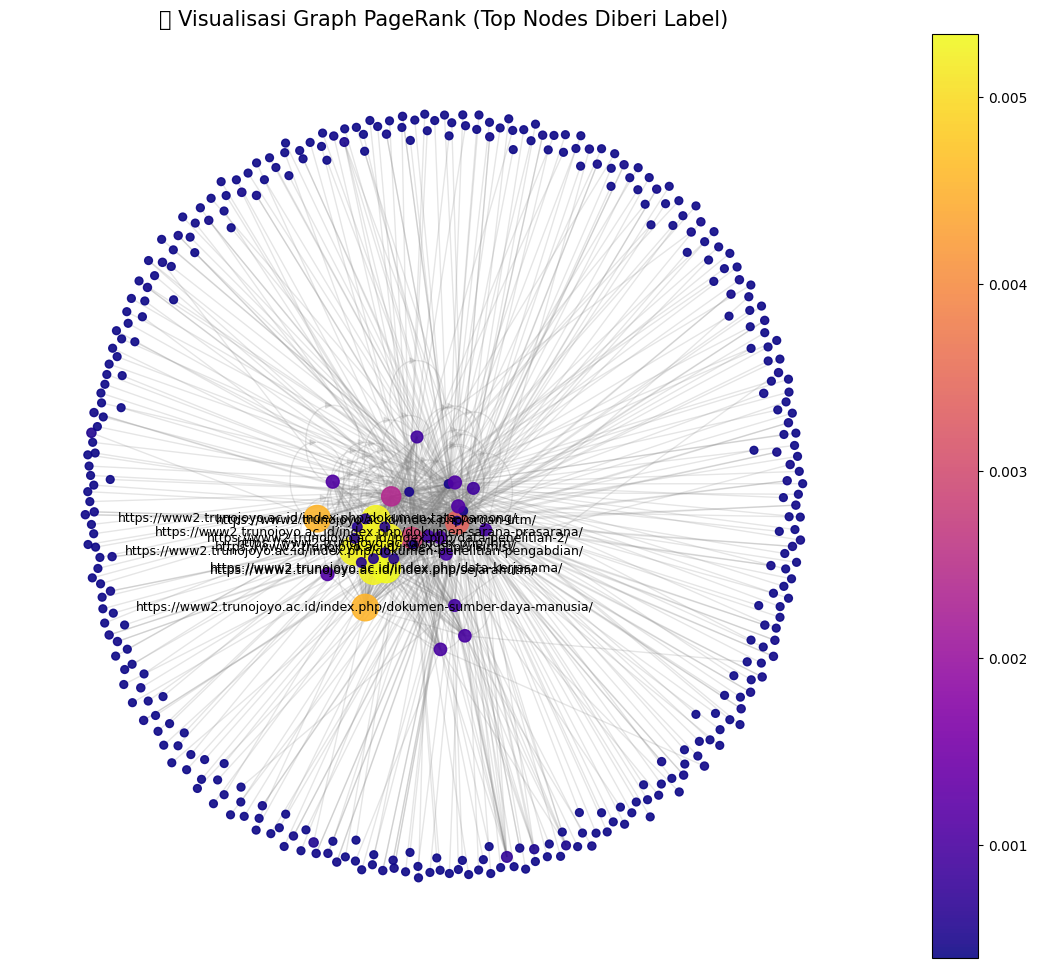

In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from tqdm.auto import tqdm

# === 1️⃣ Fungsi PageRank dengan Sparse Matrix ===
def pagerank_sparse(edges, damping=0.85, max_iter=100, tol=1e-6):
    nodes = sorted(set([s for s, _ in edges] + [t for _, t in edges]))
    n = len(nodes)
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    idx_to_node = {i: node for node, i in node_to_idx.items()}

    row, col = [], []
    for s, t in edges:
        row.append(node_to_idx[t])
        col.append(node_to_idx[s])
    data = np.ones(len(row))
    M = csr_matrix((data, (row, col)), shape=(n, n), dtype=float)

    out_degree = np.array(M.sum(axis=0)).flatten()
    out_degree[out_degree == 0] = 1.0
    M = M.multiply(1 / out_degree)

    pr = np.ones(n) / n
    teleport = (1 - damping) / n

    for i in tqdm(range(max_iter), desc="Menghitung PageRank"):
        pr_new = damping * (M @ pr) + teleport
        if np.linalg.norm(pr_new - pr, 1) < tol:
            print(f"✅ Konvergen pada iterasi ke-{i+1}")
            break
        pr = pr_new

    return {idx_to_node[i]: pr[i] for i in range(n)}


# === 2️⃣ Baca file CSV hasil crawling ===
file_path = "/content/PPWCrawlingLink.csv"
df = pd.read_csv(file_path)

# Gunakan dua kolom pertama setelah indeks
cols = df.columns[1:3]
source_col, target_col = cols[0], cols[1]

edges = list(zip(df[source_col], df[target_col]))

print(f"📊 Jumlah node unik: {len(set([s for s, _ in edges] + [t for _, t in edges]))}")
print(f"🔗 Jumlah edge: {len(edges)}")

# === 3️⃣ Hitung PageRank ===
pagerank_scores = pagerank_sparse(edges)

df_pagerank = pd.DataFrame(pagerank_scores.items(), columns=["Node", "PageRank"])
df_pagerank = df_pagerank.sort_values(by="PageRank", ascending=False)
print("\n🏆 Top 10 Node berdasarkan PageRank:")
print(df_pagerank.head(10))

# === 4️⃣ Buat graph ===
print("\n🔧 Membuat graph...")
G = nx.DiGraph()
for edge in tqdm(edges, desc="Menambahkan edges ke graph"):
    G.add_edge(*edge)

print(f"✅ Graph selesai dibuat: {G.number_of_nodes()} node dan {G.number_of_edges()} edge.")

# === 5️⃣ Visualisasi graph yang mudah dipahami ===
print("\n🎨 Membuat visualisasi graph...")

# Ambil subset agar tidak berat
subset_nodes = list(df_pagerank["Node"].head(50)) if G.number_of_nodes() > 500 else list(G.nodes())
H = G.subgraph(subset_nodes)

# Warna dan ukuran node berdasarkan PageRank
node_color = [pagerank_scores.get(node, 0) for node in H.nodes()]
node_size = [v * 80000 for v in node_color]

# Layout rapi
pos = nx.spring_layout(H, k=0.5, iterations=100, seed=42)

# Gambar edge dengan transparansi ringan agar tidak menutupi node
plt.figure(figsize=(14, 12))
nx.draw_networkx_edges(H, pos, alpha=0.2, edge_color="gray", arrows=False)

# Gambar node
nodes = nx.draw_networkx_nodes(
    H,
    pos,
    node_size=node_size,
    node_color=node_color,
    cmap=plt.cm.plasma,
    alpha=0.9
)

# Tambahkan label hanya untuk 10 node teratas (agar tidak berantakan)
top_labels = dict(df_pagerank.head(10).values)
labels = {node: node for node in H.nodes() if node in top_labels}
nx.draw_networkx_labels(H, pos, labels=labels, font_size=9, font_color='black')

# Tambahkan colorbar
plt.colorbar(nodes)
plt.title("🌐 Visualisasi Graph PageRank (Top Nodes Diberi Label)", fontsize=15)
plt.axis("off")
plt.show()
